In [1]:
# notebook to play around with intersection between ClinVar variants and dELS

In [58]:
# import packages
import pandas as pd
import numpy as np
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as mpl
import matplotlib
import torch
import os
import pybedtools
# tangermeme packages
from tangermeme.seqlet import recursive_seqlets
from tangermeme.plot import plot_logo
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme
#
from sklearn import metrics
from collections import Counter
from sklearn.metrics import RocCurveDisplay

In [25]:
# define a function for reading in data and concatenating #
def read_in_sat_mut (path2satmut, chunksize):
    # define a list for concatenating #
    chunks2cat = []
    # iterate through chunked tsv #
    for chunk in tqdm(pd.read_csv(path2satmut, sep = '\t', chunksize=chunksize)):
        chunks2cat.append(chunk)
    # concatenate chunks #
    cat_df = pd.concat(chunks2cat)
    return cat_df

In [26]:
# open clinvar bed file and encode cCRE bed file for identifying interesting examples
# clinvar bed
clinvar_bed = pybedtools.BedTool('../processed_data/clinvar_20260104_pathogenic_and_benign_variants.bed')
# K562 cCRE
k562_cCRE = pybedtools.BedTool('../raw_data/ENCFF414OGC_ENCFF806YEZ_ENCFF849TDM_ENCFF736UDR_K562_cCRE.bed')
# HepG2 cCRE
hepg2_cCRE = pybedtools.BedTool('../raw_data/ENCFF546MZK_ENCFF732PJK_ENCFF795ONN_ENCFF357NFO_HepG2_cCRE.bed')
# SKNSH cCRE
sknsh_cCRE = pybedtools.BedTool('../raw_data/ENCFF280RMA_ENCFF651WOM_ENCFF262UEH_ENCFF850MLW_SKNSH_cCRE.bed')
# ENCODE cell agnostic cCRE
all_dELS = pybedtools.BedTool.from_dataframe(pybedtools.BedTool('../processed_data/GRCh38-dELS-only.bed').to_dataframe().filter(['chrom', 'start', 'end', 'score']))

In [27]:
# define a function for filtering for only dELS from the cell type BED files
def encode_dels_only (cell_bed):
    # convert from bedtool to dataframe
    bed_df = cell_bed.to_dataframe()
    # filter for only dELS
    dELS_df = bed_df[bed_df['blockCount'] == 'dELS'].filter(['chrom', 'start', 'end', 'name'])
    dELS_bed = pybedtools.BedTool.from_dataframe(dELS_df)
    return dELS_bed

In [28]:
# filter full ENCODE cCRE BEDs for only dELS
# k562
k562_dELS = encode_dels_only(k562_cCRE)
# hepg2
hepg2_dELS = encode_dels_only(hepg2_cCRE)
# sknsh
sknsh_dELS = encode_dels_only(sknsh_cCRE)

In [29]:
clinvar_bed.head()

chr1	809284	809284	3892489;Benign;chr1:809284:T:TGGTCAATCA
 chr1	926024	926025	1555362;Likely_benign;chr1:926025:G:A
 chr1	926025	926026	2957935;Likely_benign;chr1:926026:G:T
 chr1	926025	926026	2089674;Likely_benign;chr1:926026:G:A
 chr1	926026	926027	1561208;Likely_benign;chr1:926027:C:T
 chr1	926028	926029	1624593;Likely_benign;chr1:926029:C:T
 chr1	930342	930343	1107141;Likely_benign;chr1:930343:G:T
 chr1	930342	930343	2028428;Likely_benign;chr1:930343:G:A
 chr1	930345	930346	1130596;Likely_benign;chr1:930346:C:G
 chr1	930346	930347	1528916;Likely_benign;chr1:930347:C:G
 

In [30]:
# intersect clinvar beds with the different cCREs
# k562
clinvar_k562_dELS = clinvar_bed.intersect(k562_dELS, wa=True, wb=True).to_dataframe(names=['chrom', 'start', 'end', 'clinvar_id', 'enh_chrom', 'enh_start', 'enh_end', 'enh_id'])
# hepg2
clinvar_hepg2_dELS = clinvar_bed.intersect(hepg2_dELS, wa=True, wb=True).to_dataframe(names=['chrom', 'start', 'end', 'clinvar_id', 'enh_chrom', 'enh_start', 'enh_end', 'enh_id'])
# sknsh
clinvar_sknsh_dELS = clinvar_bed.intersect(sknsh_dELS, wa=True, wb=True).to_dataframe(names=['chrom', 'start', 'end', 'clinvar_id', 'enh_chrom', 'enh_start', 'enh_end', 'enh_id'])
# agnostic cCRE
clinvar_agnostic_dELS = clinvar_bed.intersect(all_dELS, wa=True, wb=True).to_dataframe(names=['chrom', 'start', 'end', 'clinvar_id', 'enh_chrom', 'enh_start', 'enh_end', 'enh_id'])

In [31]:
# open clinvar predictions that have been annotated with clinvar, etc.
clinvar_preds = pd.read_csv('../../../clinvar/processed_data/clinvar_20260104_pathogenic_and_benign_preds.tsv', sep = '\t')
# make a dictionary of clinvar at the clinvar variant id
clinvar_clinsig_dict = dict(zip(clinvar_preds['id'], clinvar_preds['clinsig']))
# make a dictionary of clinvar id and whether the variant is an emVar
# any cell type
clinvar_emvar_dict = dict(zip(clinvar_preds['id'], clinvar_preds['emvar_any'])) # use this one for agnostic
# k562
clinvar_k_emvar_dict = dict(zip(clinvar_preds['id'], clinvar_preds['k562_emvar']))
# hepg2
clinvar_h_emvar_dict = dict(zip(clinvar_preds['id'], clinvar_preds['hepg2_emvar']))
# sknsh
clinvar_s_emvar_dict = dict(zip(clinvar_preds['id'], clinvar_preds['sknsh_emvar']))

In [32]:
# annotate each intersection with clinvar and emVar status
# k562
clinvar_k562_dELS.loc[:, 'clinsig'] = [clinvar_clinsig_dict.get(i) for i in clinvar_k562_dELS['clinvar_id']]
clinvar_k562_dELS.loc[:, 'k562_emVar'] = [clinvar_k_emvar_dict.get(i) for i in clinvar_k562_dELS['clinvar_id']]
# hepg2
clinvar_hepg2_dELS.loc[:, 'clinsig'] = [clinvar_clinsig_dict.get(i) for i in clinvar_hepg2_dELS['clinvar_id']]
clinvar_hepg2_dELS.loc[:, 'hepg2_emVar'] = [clinvar_h_emvar_dict.get(i) for i in clinvar_hepg2_dELS['clinvar_id']]
# sknsh
clinvar_sknsh_dELS.loc[:, 'clinsig'] = [clinvar_clinsig_dict.get(i) for i in clinvar_sknsh_dELS['clinvar_id']]
clinvar_sknsh_dELS.loc[:, 'sknsh_emVar'] = [clinvar_s_emvar_dict.get(i) for i in clinvar_sknsh_dELS['clinvar_id']]
# agnostic
clinvar_agnostic_dELS.loc[:, 'clinsig'] = [clinvar_clinsig_dict.get(i) for i in clinvar_agnostic_dELS['clinvar_id']]
clinvar_agnostic_dELS.loc[:, 'emVar_any'] = [clinvar_emvar_dict.get(i) for i in clinvar_agnostic_dELS['clinvar_id']]

In [33]:
clinvar_k562_dELS[(clinvar_k562_dELS['clinsig'].isin(['Pathogenic', 'Likely_pathogenic'])) & (clinvar_k562_dELS['k562_emVar'] == 1)]

,chrom,start,end,clinvar_id,enh_chrom,enh_start,enh_end,enh_id,clinsig,k562_emVar
129,chr10,77983868,77983869,3068444;Likely_pathogenic;chr10:77983869:T:C,chr10,77983813,77984163,EH38E1481416,Likely_pathogenic,1


In [34]:
clinvar_hepg2_dELS[(clinvar_hepg2_dELS['clinsig'].isin(['Pathogenic', 'Likely_pathogenic'])) & (clinvar_hepg2_dELS['hepg2_emVar'] == 1)]

,chrom,start,end,clinvar_id,enh_chrom,enh_start,enh_end,enh_id,clinsig,hepg2_emVar
325,chr17,44001598,44001599,1177297;Likely_pathogenic;chr17:44001599:A:T,chr17,44001427,44001769,EH38E3225287,Likely_pathogenic,1


In [35]:
clinvar_sknsh_dELS[(clinvar_sknsh_dELS['clinsig'].isin(['Pathogenic', 'Likely_pathogenic'])) & (clinvar_sknsh_dELS['sknsh_emVar'] == 1)]

,chrom,start,end,clinvar_id,enh_chrom,enh_start,enh_end,enh_id,clinsig,sknsh_emVar


In [36]:
clinvar_agnostic_dELS[(clinvar_agnostic_dELS['clinsig'].isin(['Pathogenic', 'Likely_pathogenic'])) & (clinvar_agnostic_dELS['emVar_any'] == 1)]

,chrom,start,end,clinvar_id,enh_chrom,enh_start,enh_end,enh_id,clinsig,emVar_any
5328,chr10,12100262,12100263,3649028;Likely_pathogenic;chr10:12100263:G:A,chr10,12099983,12100331,EH38E2886384,Likely_pathogenic,1
6640,chr10,77983868,77983869,3068444;Likely_pathogenic;chr10:77983869:T:C,chr10,77983813,77984163,EH38E1481416,Likely_pathogenic,1
8752,chr11,31790702,31790702,2576696;Pathogenic;chr11:31790702:TGGCTCAC:G,chr11,31790495,31790707,EH38E1530173,Pathogenic,1
21510,chr16,88840058,88840059,3600991;Likely_pathogenic;chr16:88840059:C:A,chr16,88839965,88840249,EH38E3199868,Likely_pathogenic,1
23579,chr17,44001598,44001599,1177297;Likely_pathogenic;chr17:44001599:A:T,chr17,44001427,44001769,EH38E3225287,Likely_pathogenic,1
25513,chr17,80108466,80108467,370278;Pathogenic;chr17:80108467:T:G,chr17,80108376,80108725,EH38E3248667,Pathogenic,1
26420,chr18,23552735,23552736,553804;Pathogenic;chr18:23552736:C:T,chr18,23552585,23552810,EH38E1904170,Pathogenic,1
53424,chr7,156791254,156791255,4903;Pathogenic;chr7:156791255:G:C,chr7,156791138,156791339,EH38E3811391,Pathogenic,1
53425,chr7,156791256,156791257,3340528;Pathogenic;chr7:156791257:G:A,chr7,156791138,156791339,EH38E3811391,Pathogenic,1
53565,chr8,11474237,11474238,12322;Pathogenic;chr8:11474238:G:A,chr8,11474154,11474504,EH38E2610757,Pathogenic,1


In [37]:
def plot_specific_logos (annotated_seqlets,
                         cell,
                         enhancerID,
                         plotLogo_tensors,
                         save):
    # define colors for each cell type for highlighting logos
    if cell == 'K562':
        highlight = '#00A79D'
    elif cell == 'HepG2':
        highlight = '#FBB040'
    elif cell == 'SKNSH':
        highlight = '#ED1C24'
    print(cell)
    # return index of chosen enhancer
    enh_idx = list(plotLogo_tensors['K562'].keys()).index(enhancerID)
    cell_seqlets = annotated_seqlets[cell][0]
    annotation_seqlets = annotated_seqlets[cell][-1]
    # filter for the random enhancer by enhancer index
    enh_seqlets = cell_seqlets[cell_seqlets['example_idx'] == enh_idx]
    enh_ann = annotation_seqlets.iloc[enh_seqlets.index]
    if len(enh_seqlets) > 0:
        mpl.figure(figsize=(20,4), dpi=300)
        ax = mpl.subplot(111)
        matplotlib.rcParams['pdf.fonttype'] = 42
        matplotlib.rcParams['ps.fonttype'] = 42
        plot_logo(plotLogo_tensors[cell][enhancerID], annotations=enh_ann, score_key='attribution')
        for idx, row in enh_seqlets.iterrows():
            start, stop = row[['start', 'end']].tolist()
            ax.axvspan(start - 0.5, stop + 0.5, alpha=0.25, color=highlight)
        #mpl.ylim(-.5, .5)
        mpl.title(f'tangermeme seqlets for {enhancerID}, threshold: 0.01 | {cell}')
        mpl.tight_layout()
        if save == True:
            mpl.savefig(f'{enhancerID}_sat_mut_logos.pdf')
    else:
        print('no seqlets for this enhancer at this threshold')
        mpl.figure(figsize=(20,1), dpi=300)
        plot_logo(plotLogo_tensors[cell][enhancerID])
        mpl.title(f'tangermeme seqlets for {enhancerID}, threshold: 0.01 | {cell}')
        mpl.show()

In [38]:
# define function for plotting logos including opening preds, etc.
def plot_logos_v2 (chrom,
                   cell,
                   enhancer_id):
    # load plotLogo_tensors
    plotLogos = torch.load(f'/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/seqlets_calling/seqlets_by_chrom/chr{chrom}_plotLogo_tensors.pt')
    # load annotated seqlets
    ann_seqlets = torch.load(f'/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/seqlets_calling/seqlets_by_chrom/annotated_seqlets/chr{chrom}_annotated_seqlets_0.01.pt',
                             weights_only=False)
    # plot the logo
    plot_specific_logos(
        ann_seqlets,
        cell,
        enhancer_id,
        plotLogos,
        False
    )


K562


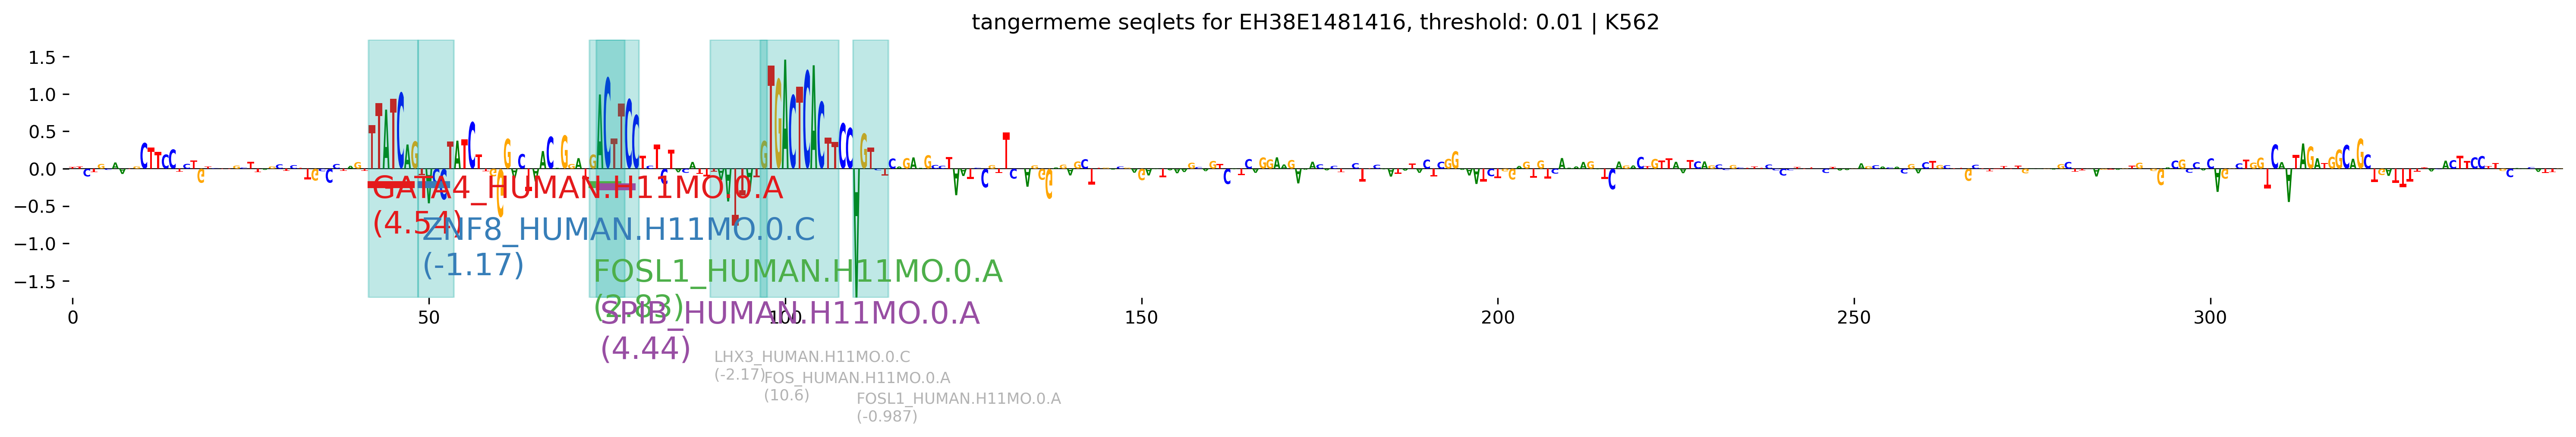

In [39]:
# k562
# chr10 	77983813 	77984163 	EH38E1481416 	Likely_pathogenic 	
plot_logos_v2(
    10,
    'K562',
    'EH38E1481416'
)

HepG2


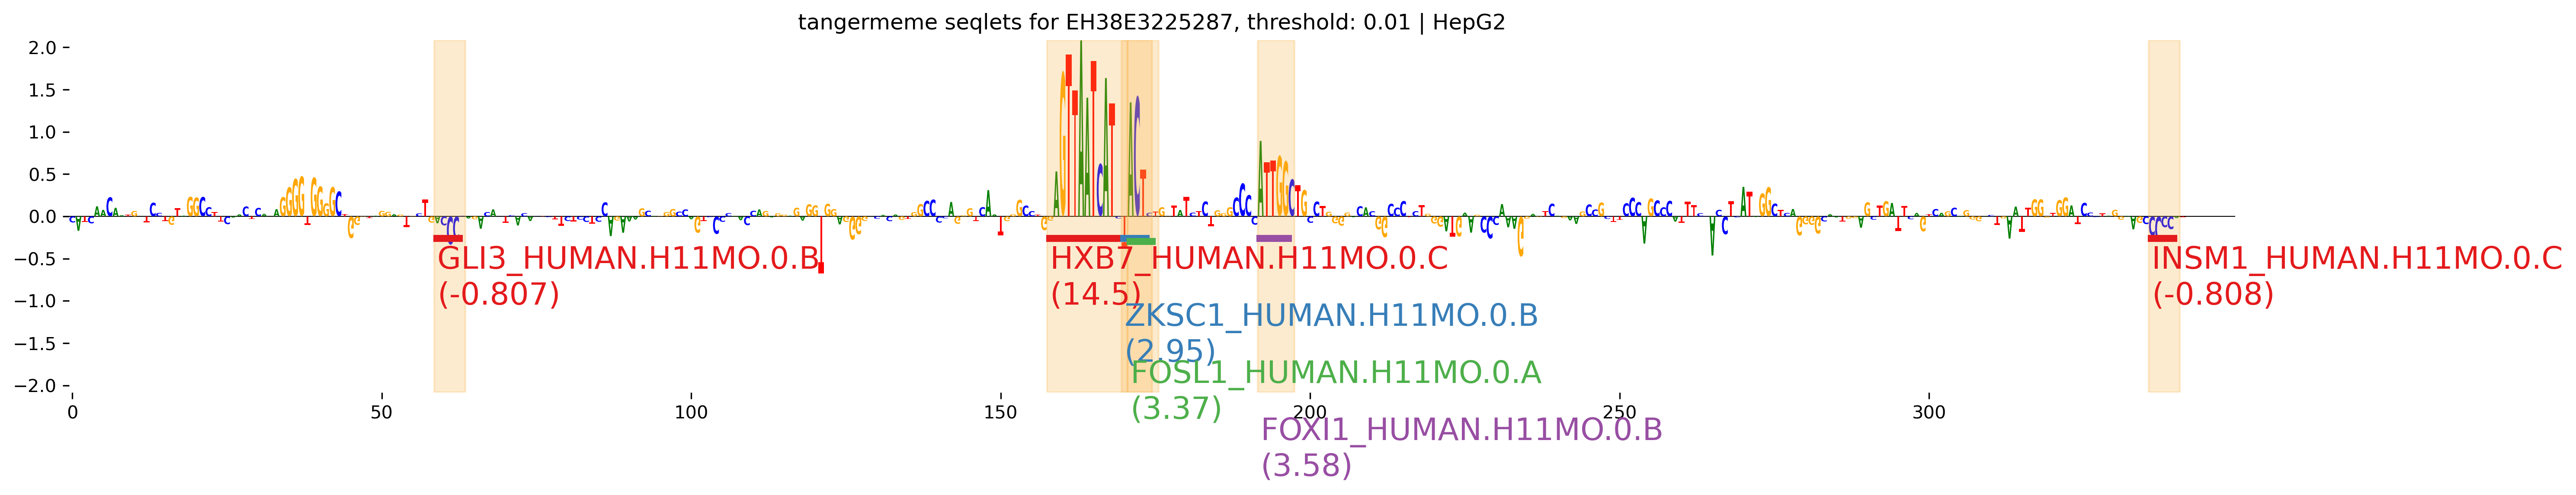

In [40]:
# hepg2
# chr17 	44001427 	44001769 	EH38E3225287 	Likely_pathogenic
plot_logos_v2(
    17,
    'HepG2',
    'EH38E3225287'
)

K562
HepG2
SKNSH


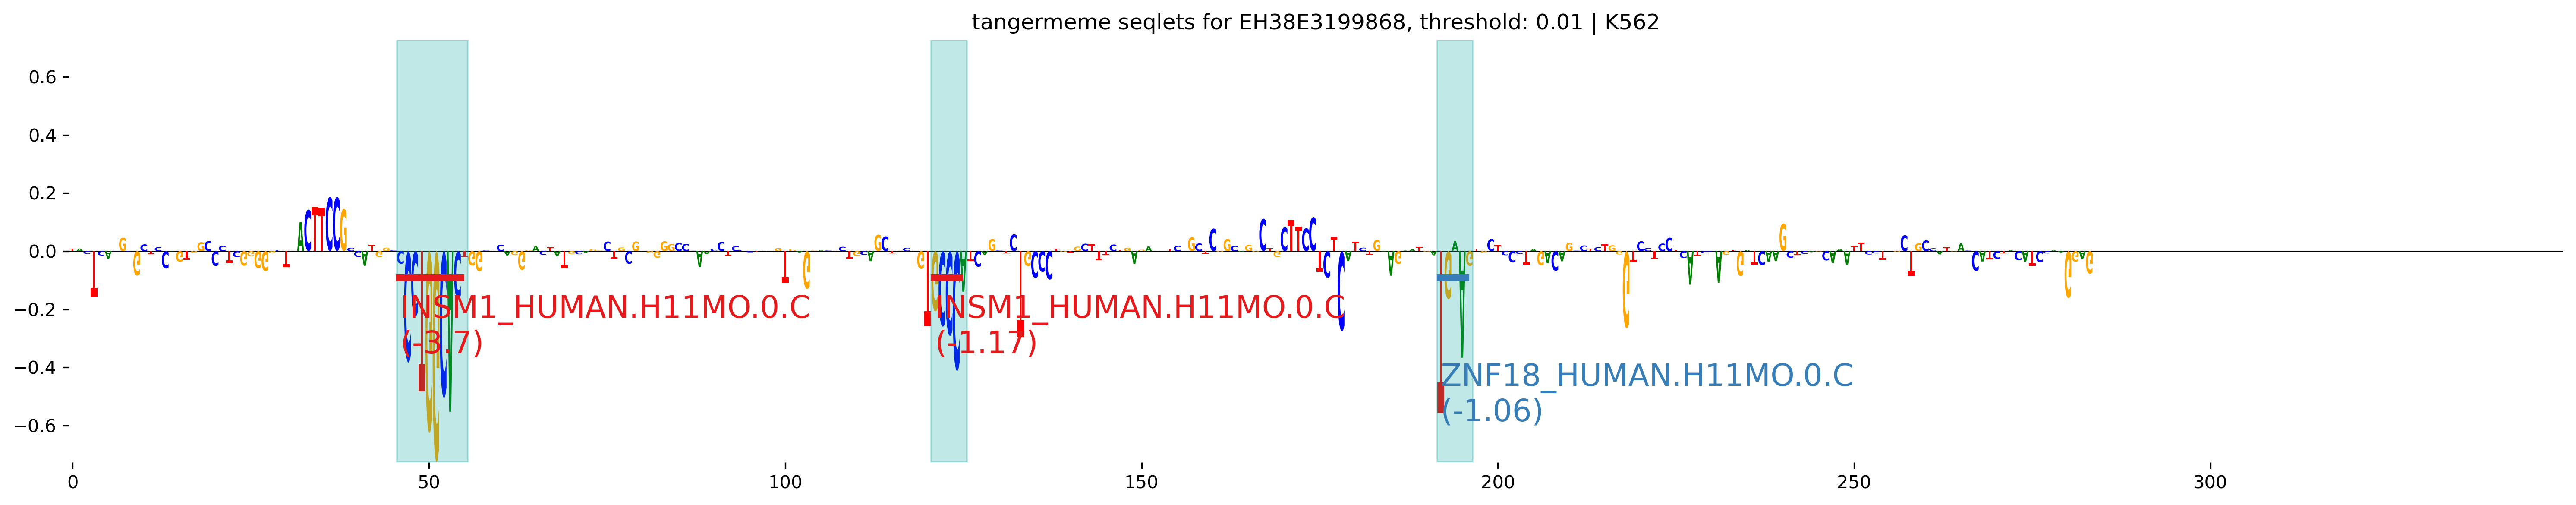

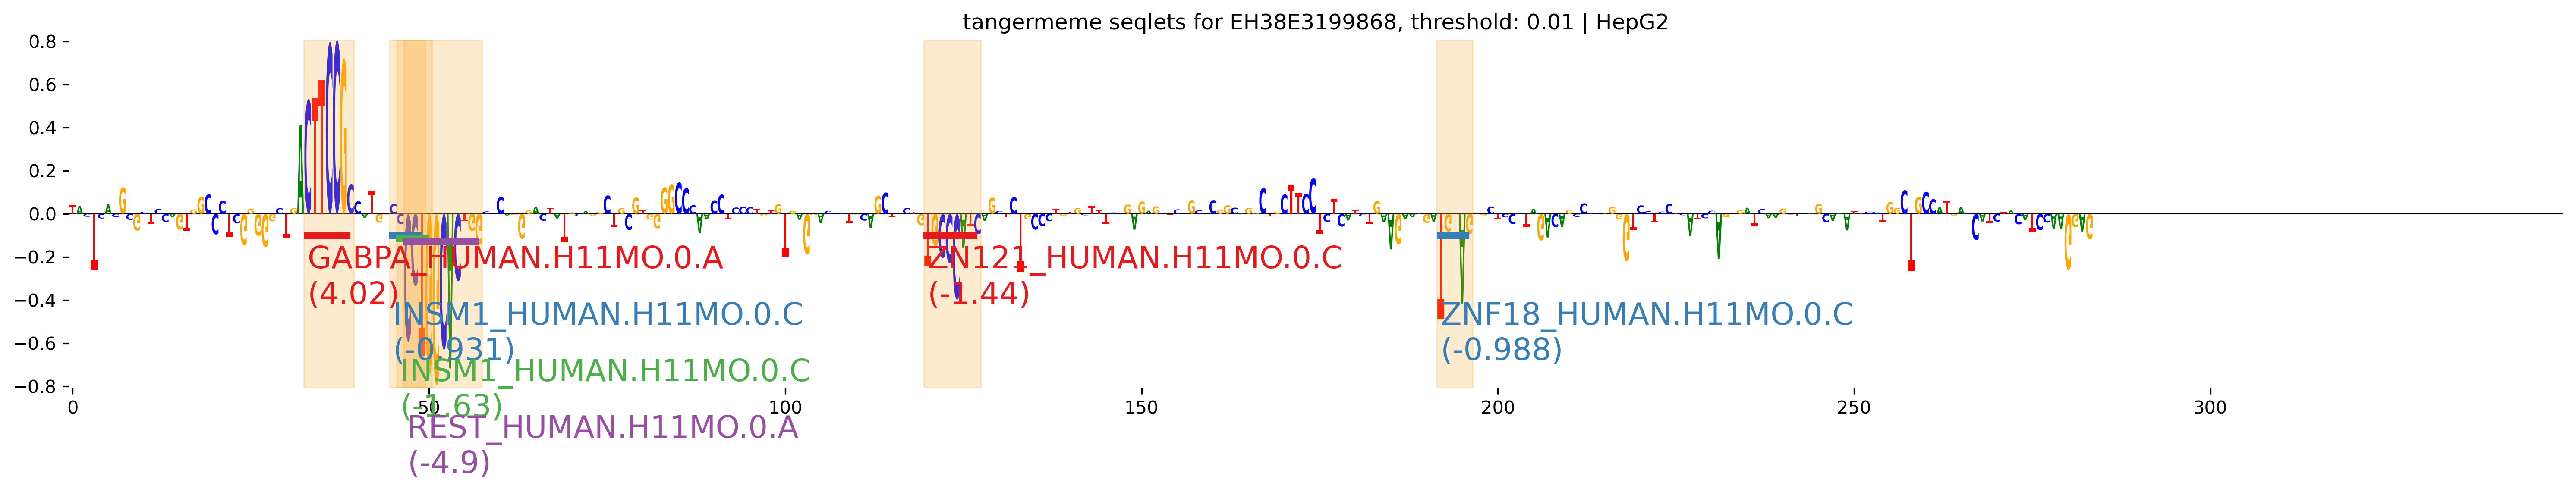

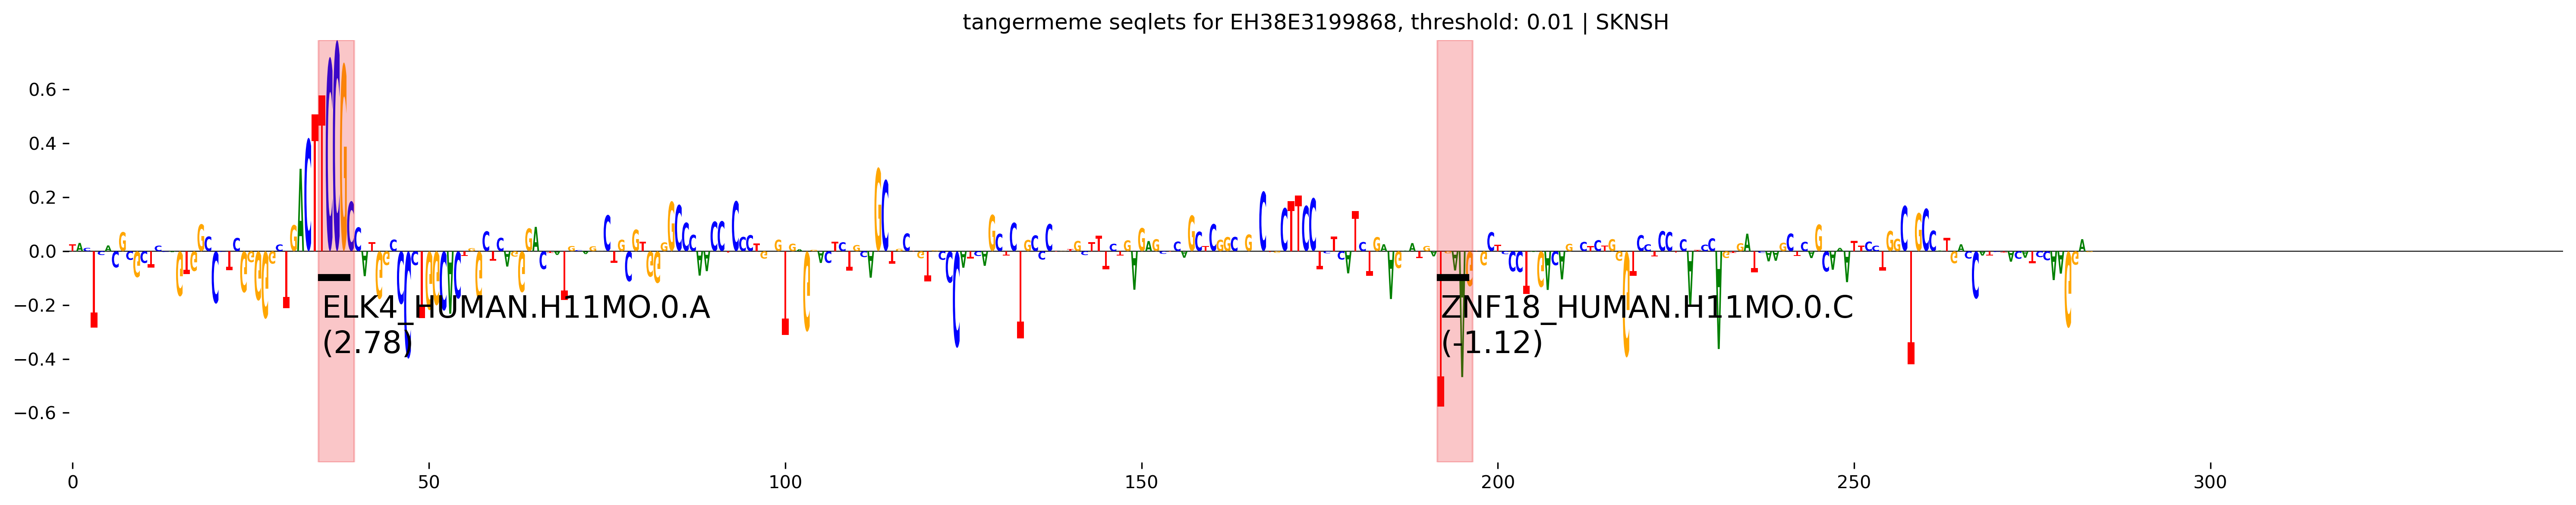

In [41]:
# cell type agnostic
# chr16 	88839965 	88840249 	EH38E3199868 	Likely_pathogenic
plot_logos_v2(
    16,
    'K562',
    'EH38E3199868'
)
plot_logos_v2(
    16,
    'HepG2',
    'EH38E3199868'
)
plot_logos_v2(
    16,
    'SKNSH',
    'EH38E3199868'
)

K562
HepG2
SKNSH


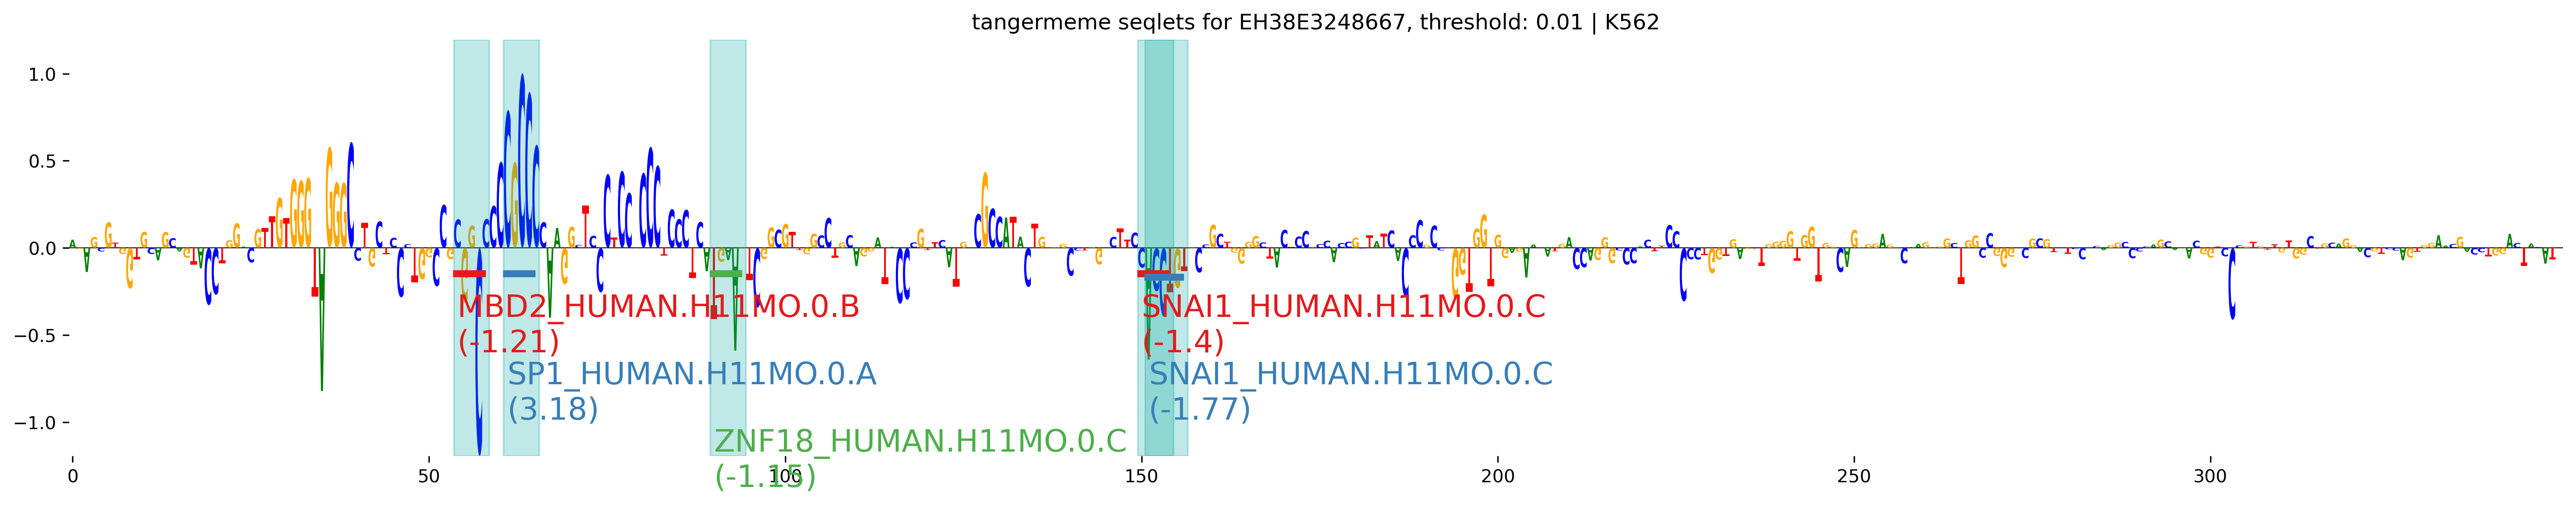

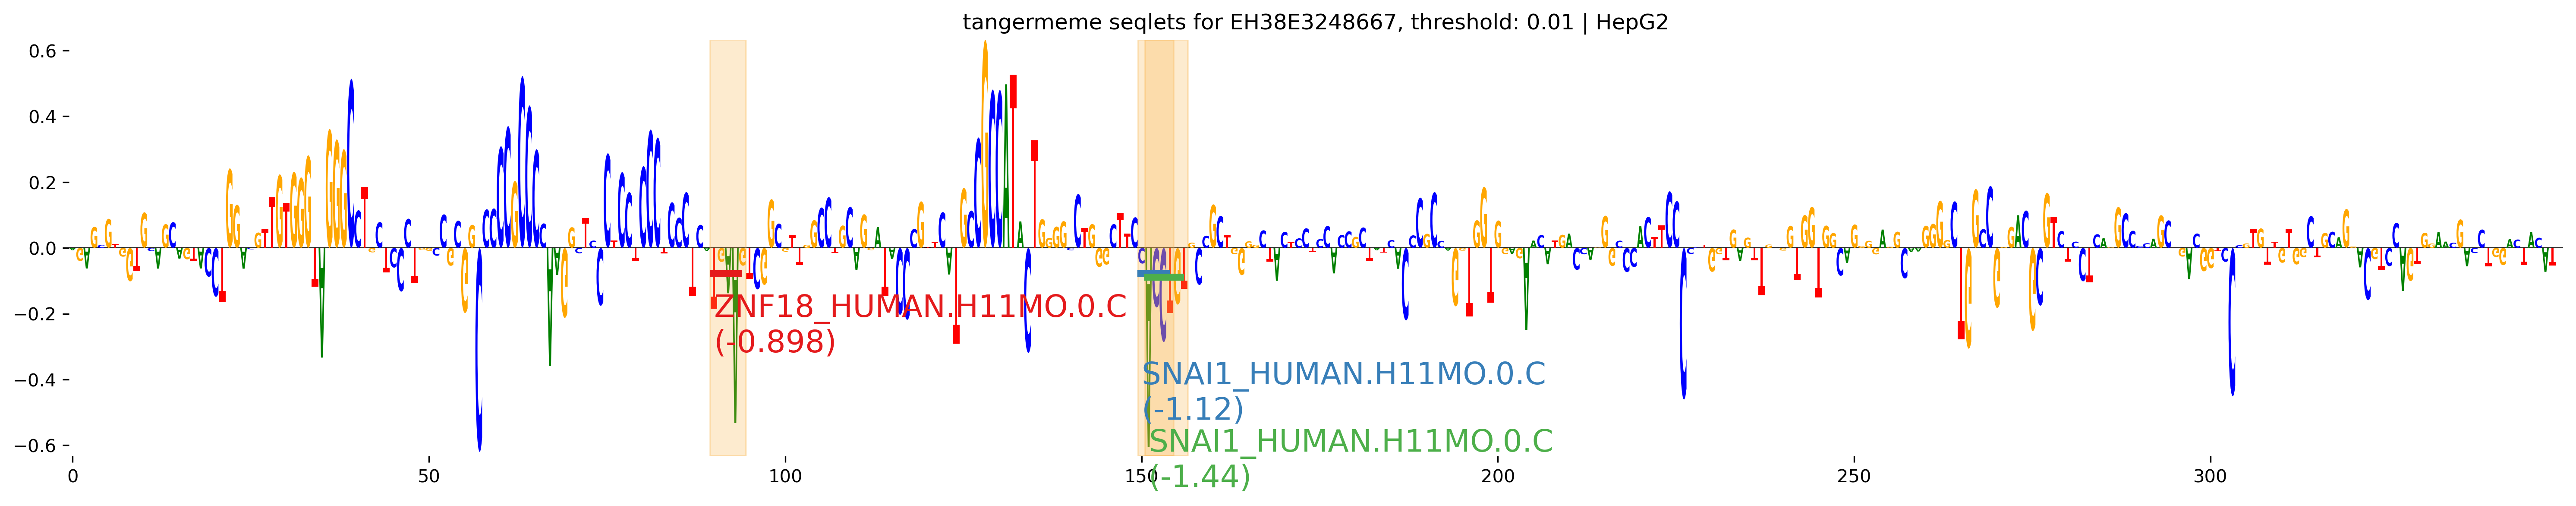

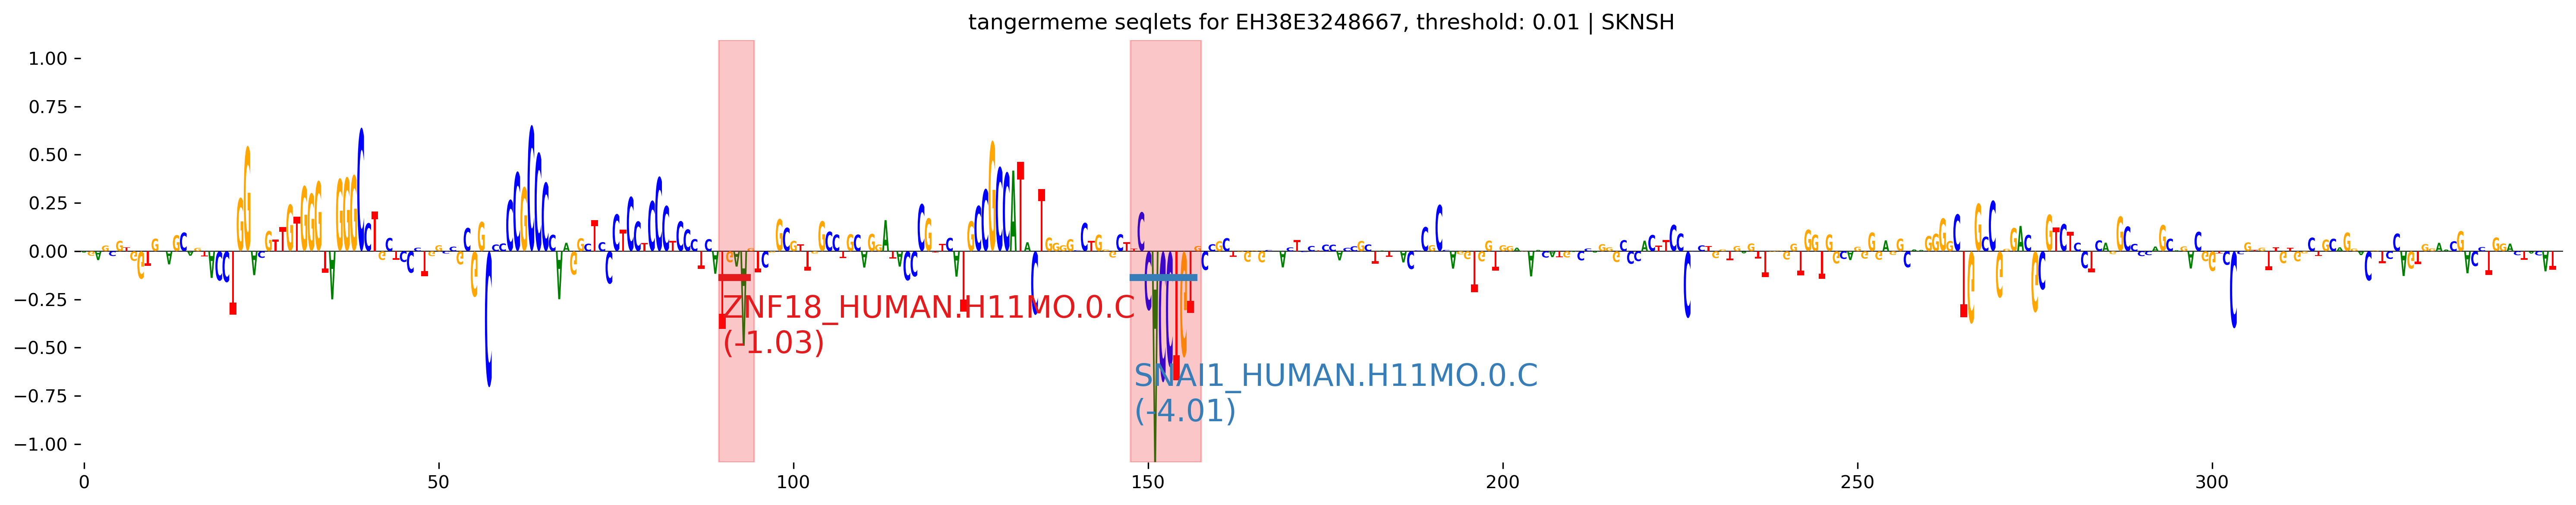

In [42]:
# emvar any
# chr17 	80108376 	80108725 	EH38E3248667 	Pathogenic 	
plot_logos_v2(
    17,
    'K562',
    'EH38E3248667'
)
plot_logos_v2(
    17,
    'HepG2',
    'EH38E3248667'
)
plot_logos_v2(
    17,
    'SKNSH',
    'EH38E3248667'
)

In [43]:
clinvar_preds[clinvar_preds['id'] == '370278;Pathogenic;chr17:80108467:T:G'].filter(['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred'])

,k562_skew_pred,hepg2_skew_pred,sknsh_skew_pred
35813,0.936298,0.822291,0.946148


K562
HepG2
SKNSH


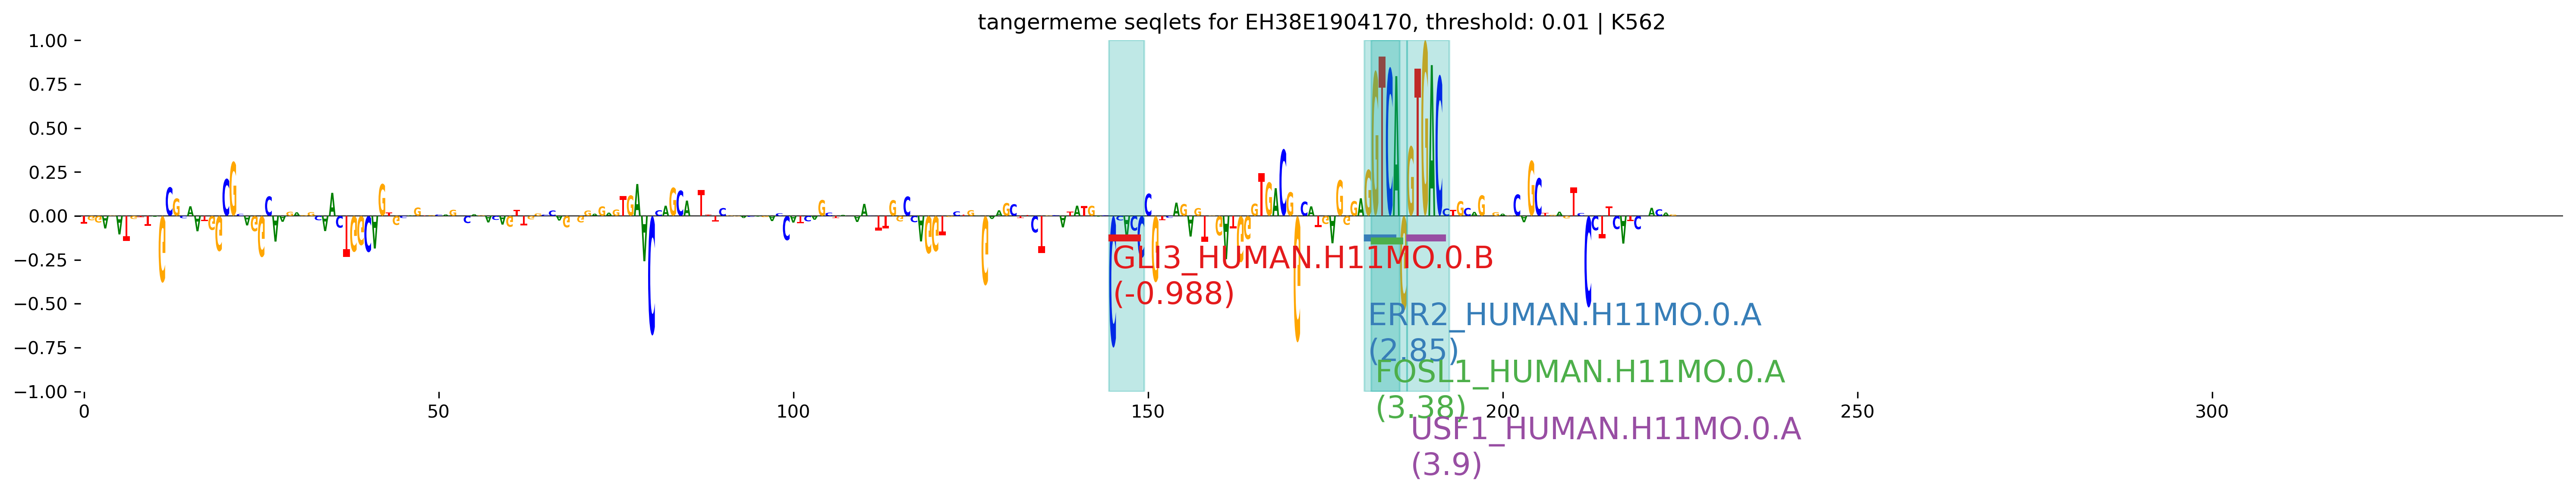

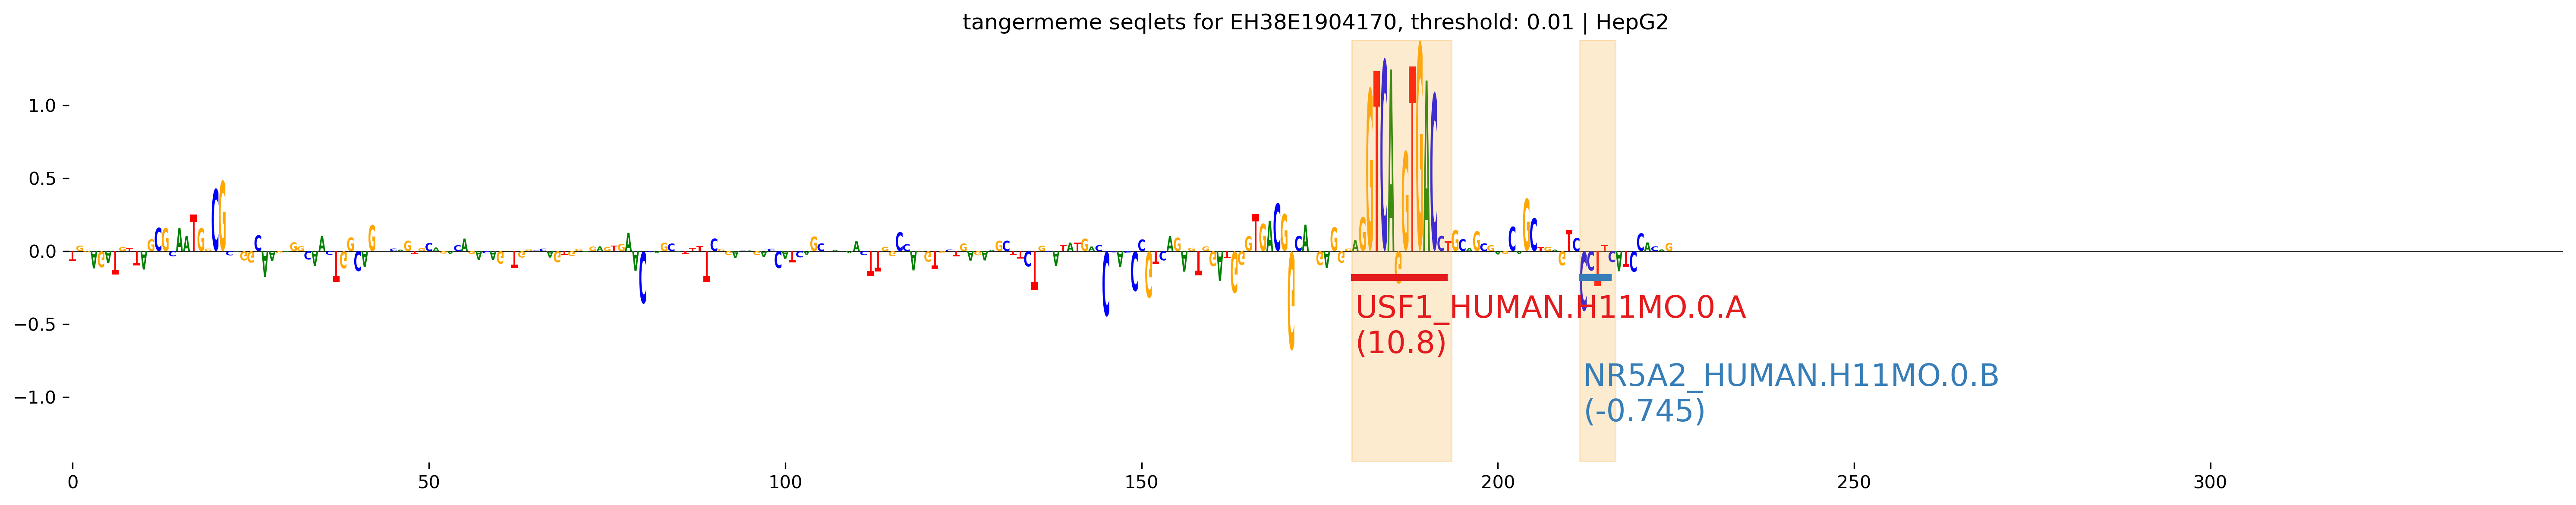

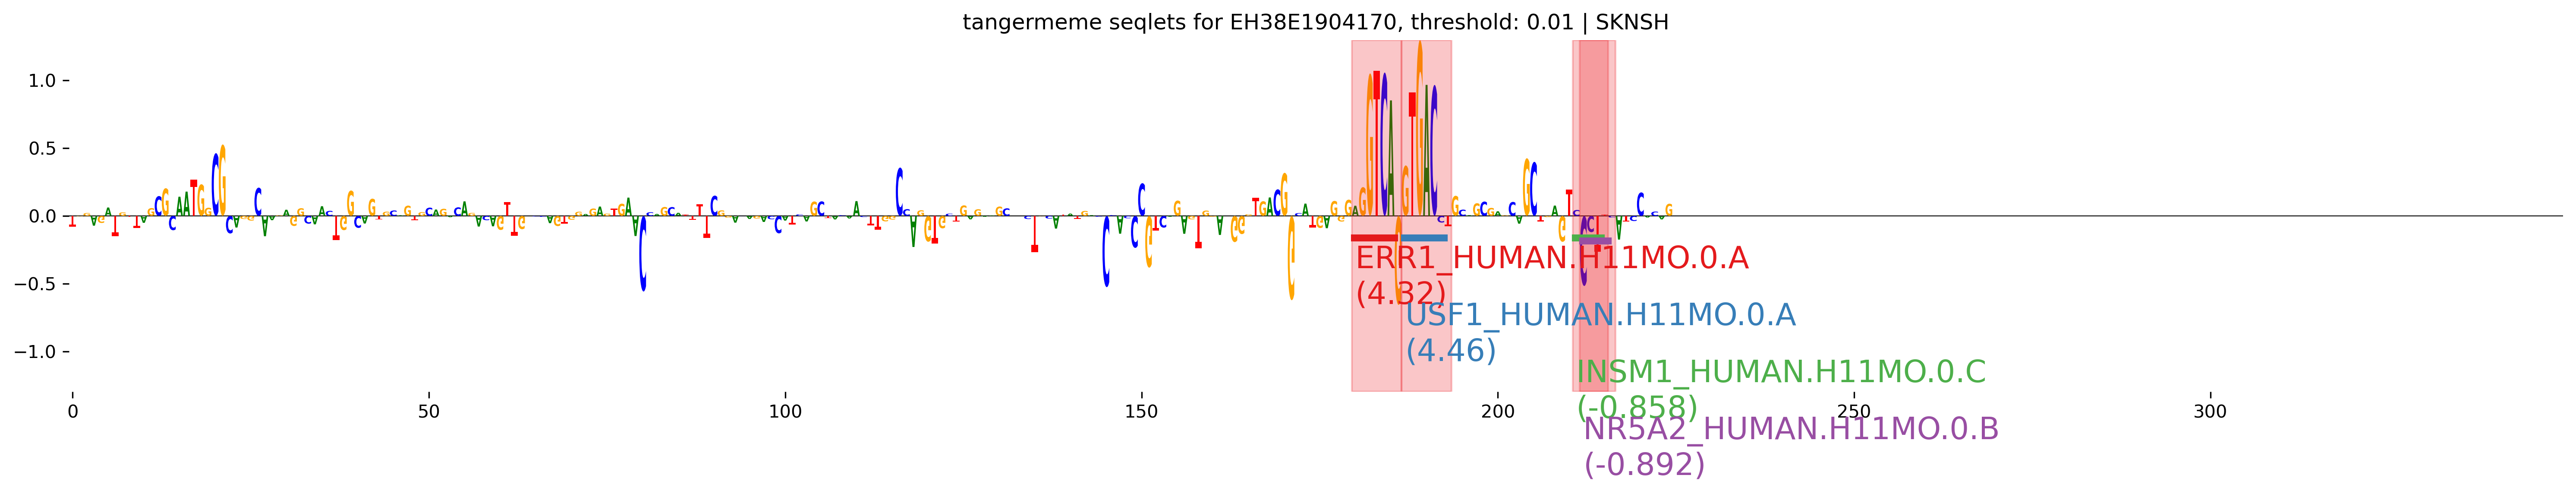

In [44]:
# emvar any
# chr18 	23552585 	23552810 	EH38E1904170
plot_logos_v2(
    18,
    'K562',
    'EH38E1904170'
)
plot_logos_v2(
    18,
    'HepG2',
    'EH38E1904170'
)
plot_logos_v2(
    18,
    'SKNSH',
    'EH38E1904170'
)

In [45]:
clinvar_preds[clinvar_preds['id'] == '553804;Pathogenic;chr18:23552736:C:T'].filter(['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred'])

,k562_skew_pred,hepg2_skew_pred,sknsh_skew_pred
88418,-0.475012,-0.583196,-0.894865


K562
HepG2
SKNSH


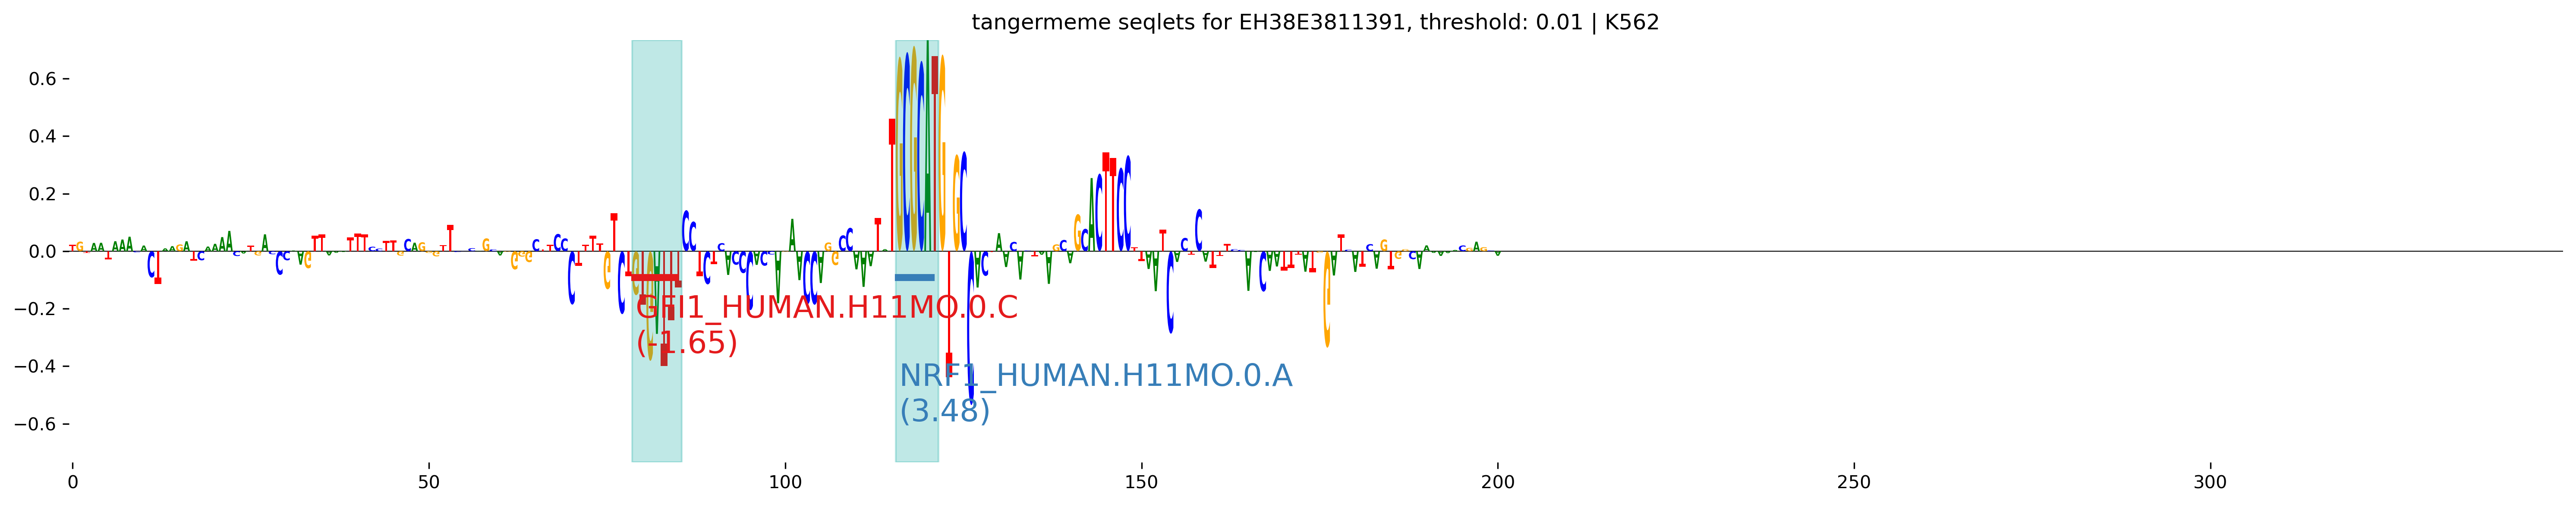

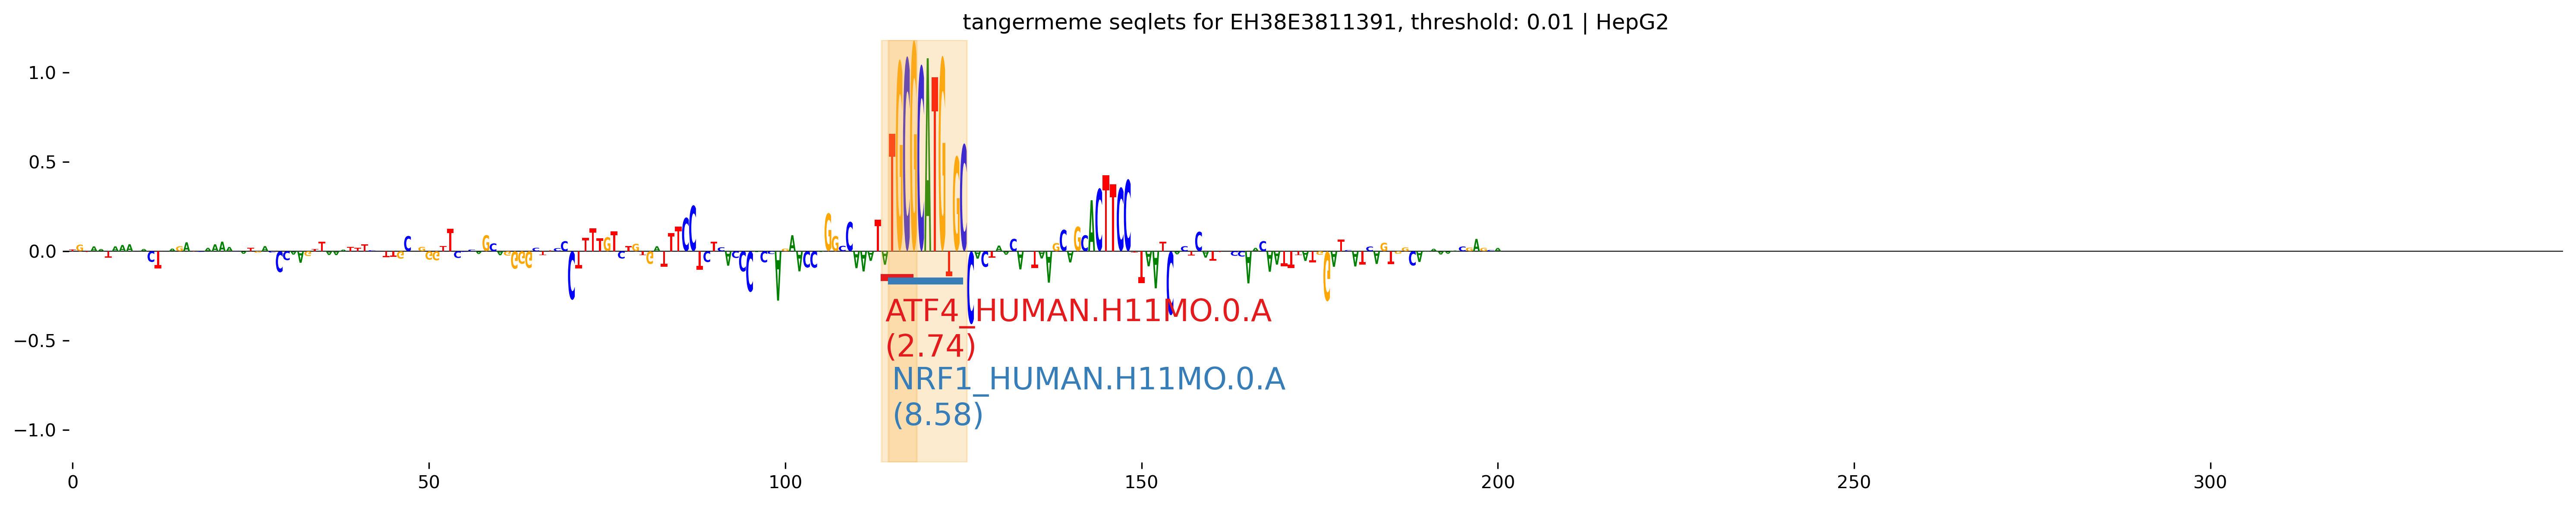

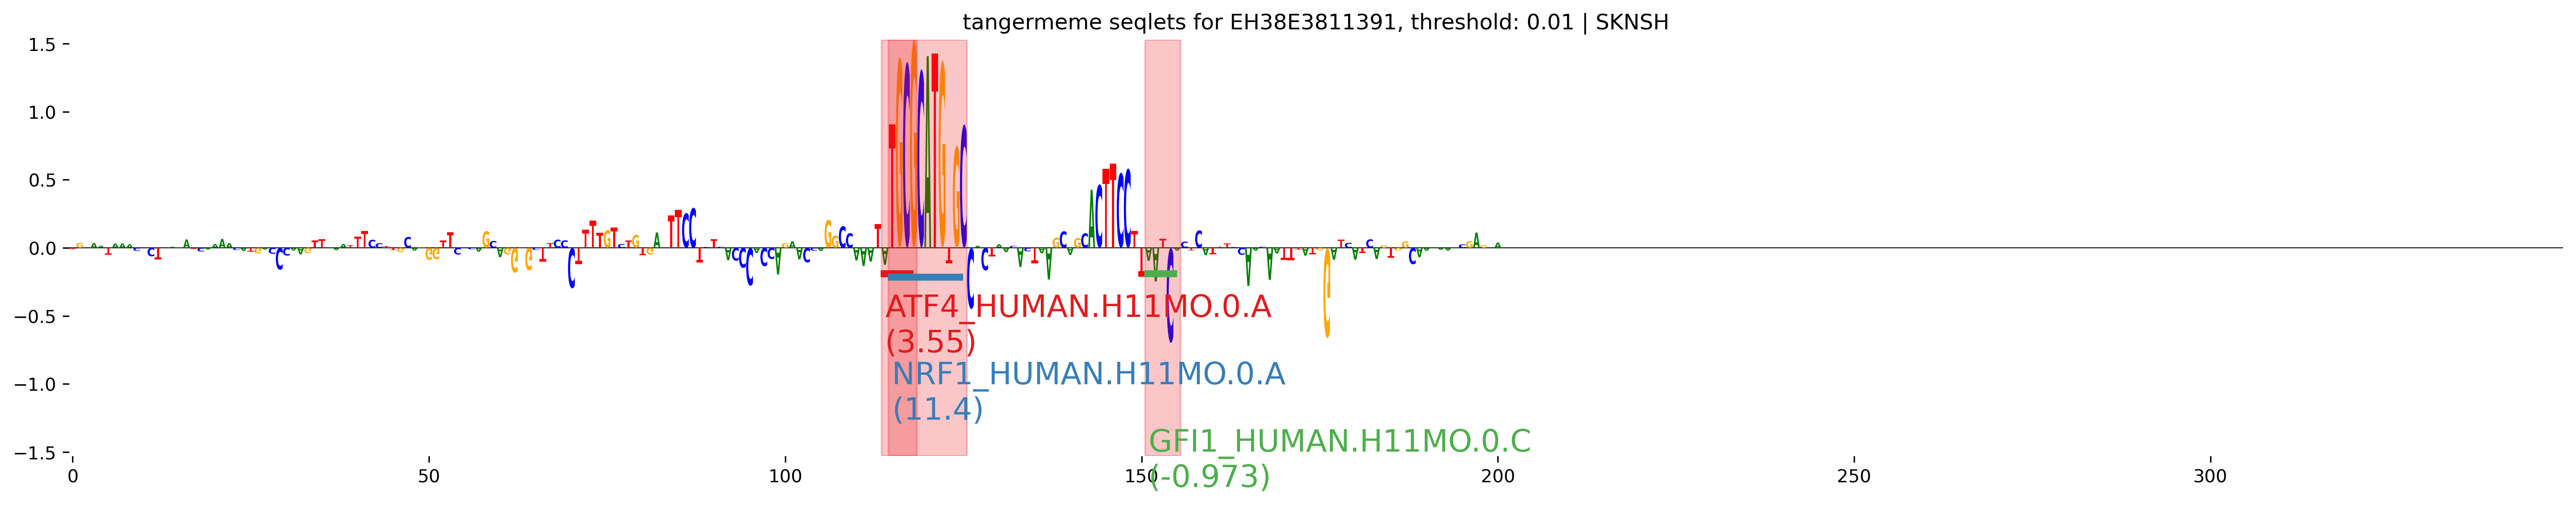

In [46]:
# emvar any ***
# chr7 	156791138 	156791339 	EH38E3811391 	Pathogenic
plot_logos_v2(
    7,
    'K562',
    'EH38E3811391'
)
plot_logos_v2(
    7,
    'HepG2',
    'EH38E3811391'
)
plot_logos_v2(
    7,
    'SKNSH',
    'EH38E3811391'
)

In [47]:
clinvar_preds[clinvar_preds['id'].isin(['4903;Pathogenic;chr7:156791255:G:C', 
                                        '3340528;Pathogenic;chr7:156791257:G:A'])].filter(['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'k562_ref_pred', 'hepg2_ref_pred', 'sknsh_ref_pred'])

,k562_skew_pred,hepg2_skew_pred,sknsh_skew_pred,k562_ref_pred,hepg2_ref_pred,sknsh_ref_pred
74235,-0.723023,-1.152652,-1.501941,0.875866,1.707423,2.162487
74236,-0.671991,-1.131608,-1.530791,0.919855,1.709611,2.148087


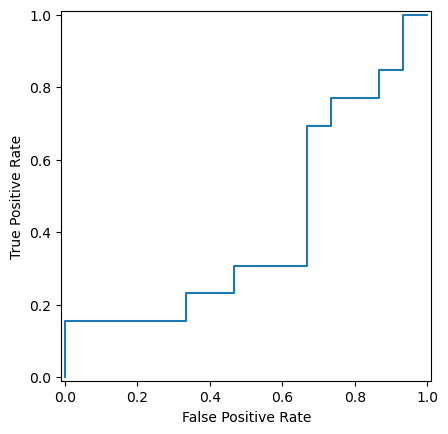

In [65]:
zrs_rough = clinvar_preds[(clinvar_preds['chrom'] == 'chr7') & (clinvar_preds['pos'] >= 156791139) & (clinvar_preds['pos'] <= 156791613)].copy()
# take the average skew of each cell type
zrs_rough.loc[:, 'mean_skew_pred'] = [np.mean([k,h,s]) for k,h,s in zip(zrs_rough['k562_skew_pred'], zrs_rough['hepg2_skew_pred'], zrs_rough['sknsh_skew_pred'])]
# take absolute value of skew
zrs_rough.loc[:, 'abs_mean_skew'] = zrs_rough['mean_skew_pred'].abs()
# add binary for auroc
zrs_rough.loc[:,'zrs_TrueFalse'] = [1 if i in ['Pathogenic', 'Likely_pathogenic'] else 0 for i in zrs_rough['clinsig']]

# generate auROC curve #
fpr, tpr, thresh = metrics.roc_curve(zrs_rough['zrs_TrueFalse'],
                                     zrs_rough['abs_mean_skew'])
# generate auROC score #
auroc_score = metrics.roc_auc_score(zrs_rough['zrs_TrueFalse'],
                                    zrs_rough['abs_mean_skew'])
# display roc curve #
RocCurveDisplay(fpr=fpr,
                tpr=tpr).plot()

In [66]:
auroc_score

0.4153846153846154

In [51]:
clinvar_preds[(clinvar_preds['chrom'] == 'chr7') & (clinvar_preds['pos'] >= 156791139) & (clinvar_preds['pos'] <= 156791613)].filter(['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred', 'clinsig'])

,k562_skew_pred,hepg2_skew_pred,sknsh_skew_pred,clinsig
74232,-0.081206,0.023698,0.029239,Likely_benign
74233,0.015955,0.024479,0.046753,Likely_benign
74234,0.477198,0.534420,0.800227,Likely_benign
74235,-0.723023,-1.152652,-1.501941,Pathogenic
74236,-0.671991,-1.131608,-1.530791,Pathogenic
74237,-0.027054,-0.002736,-0.032416,Likely_benign
74238,0.074384,0.134994,0.185978,Likely_benign
74239,-0.000181,0.017042,0.025315,Benign
74240,0.064070,0.076196,0.041714,Likely_benign
74241,0.097792,0.079156,0.023709,Likely_benign


K562
HepG2
SKNSH


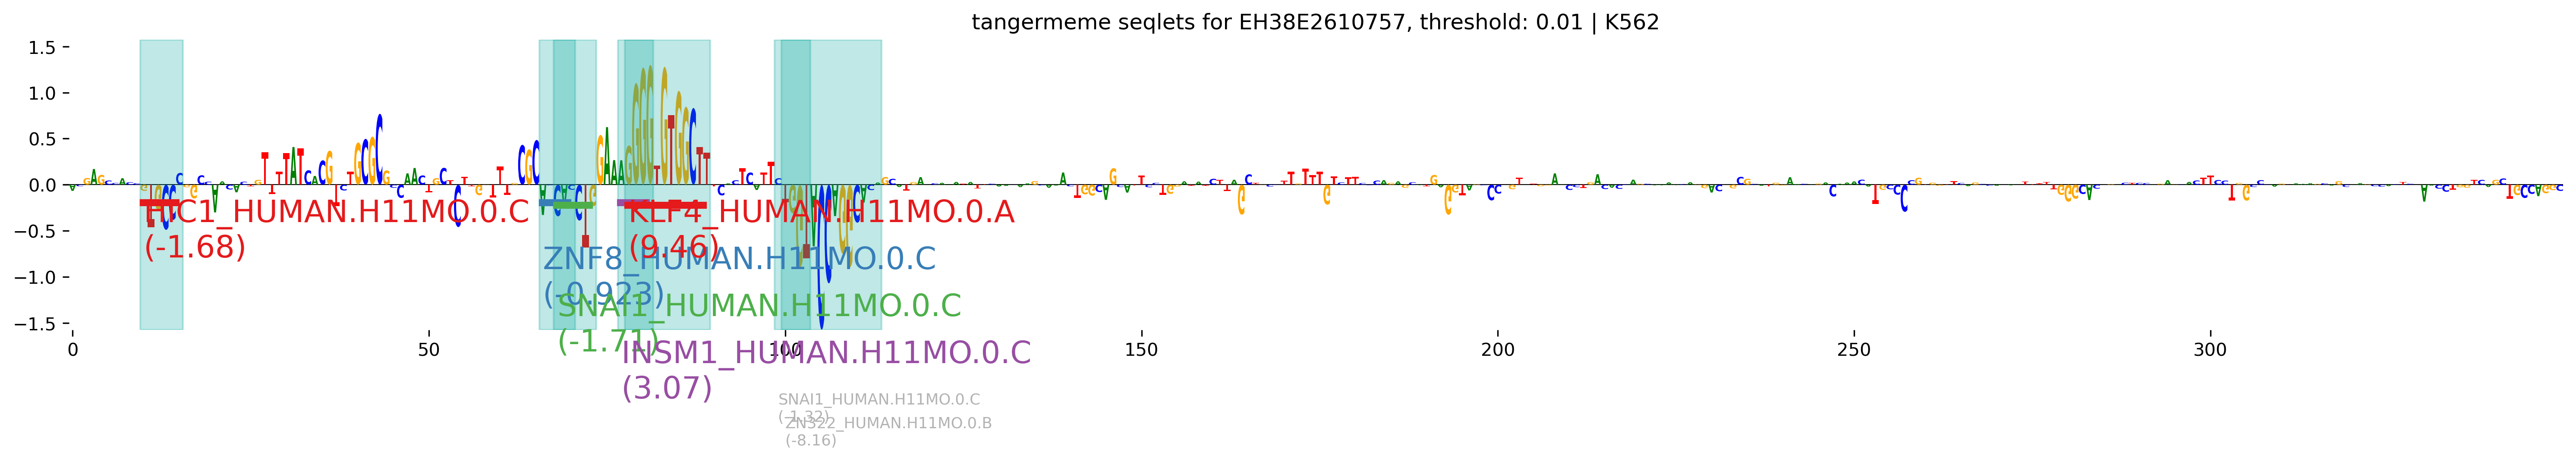

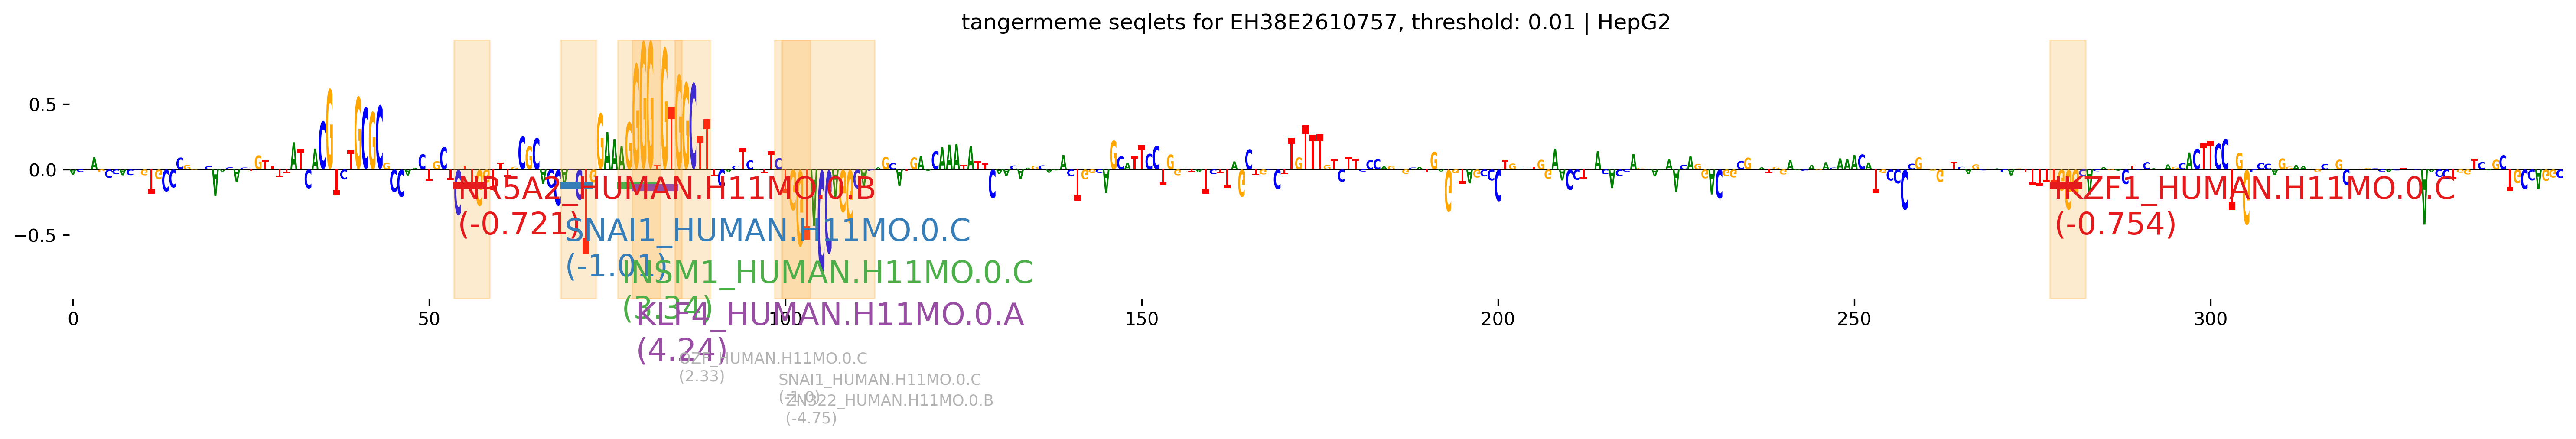

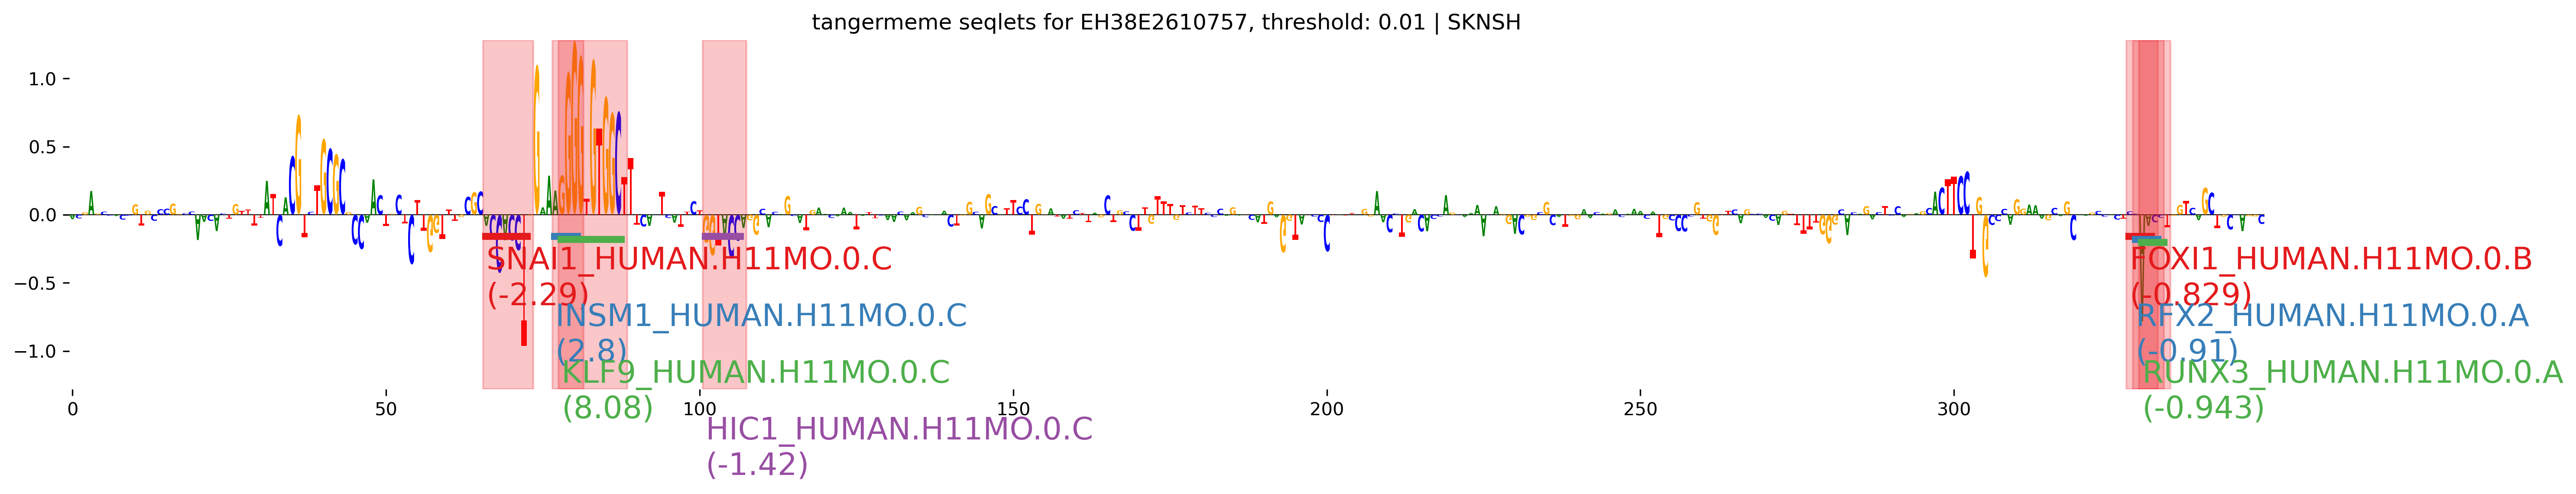

In [17]:
# emvar any ***
# chr8 	11474154 	11474504 	EH38E2610757 	Pathogenic
plot_logos_v2(
    8,
    'K562',
    'EH38E2610757'
)
plot_logos_v2(
    8,
    'HepG2',
    'EH38E2610757'
)
plot_logos_v2(
    8,
    'SKNSH',
    'EH38E2610757'
)

In [64]:
clinvar_preds[clinvar_preds['id'] == '12322;Pathogenic;chr8:11474238:G:A'].filter(['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred'])

,k562_skew_pred,hepg2_skew_pred,sknsh_skew_pred
185429,-1.315668,-0.97037,-1.153227


In [66]:
clinvar_preds[(clinvar_preds['chrom'] == 'chr8') & (clinvar_preds['pos'] == 11474237)].filter(['k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred'])

,k562_skew_pred,hepg2_skew_pred,sknsh_skew_pred
185428,-0.171988,0.078902,0.083466


K562
HepG2
SKNSH
no seqlets for this enhancer at this threshold


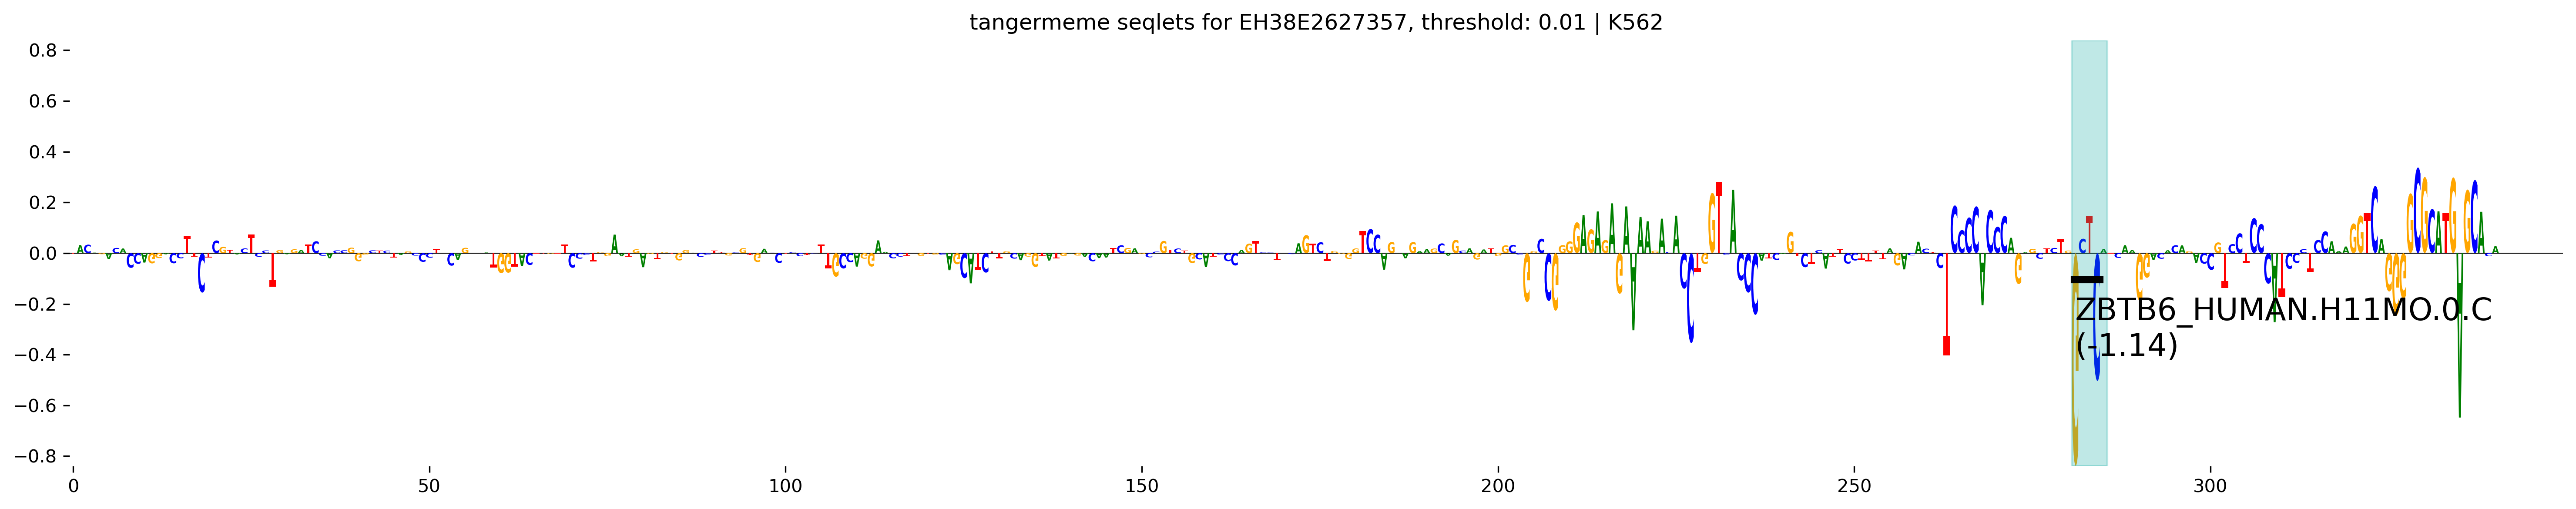

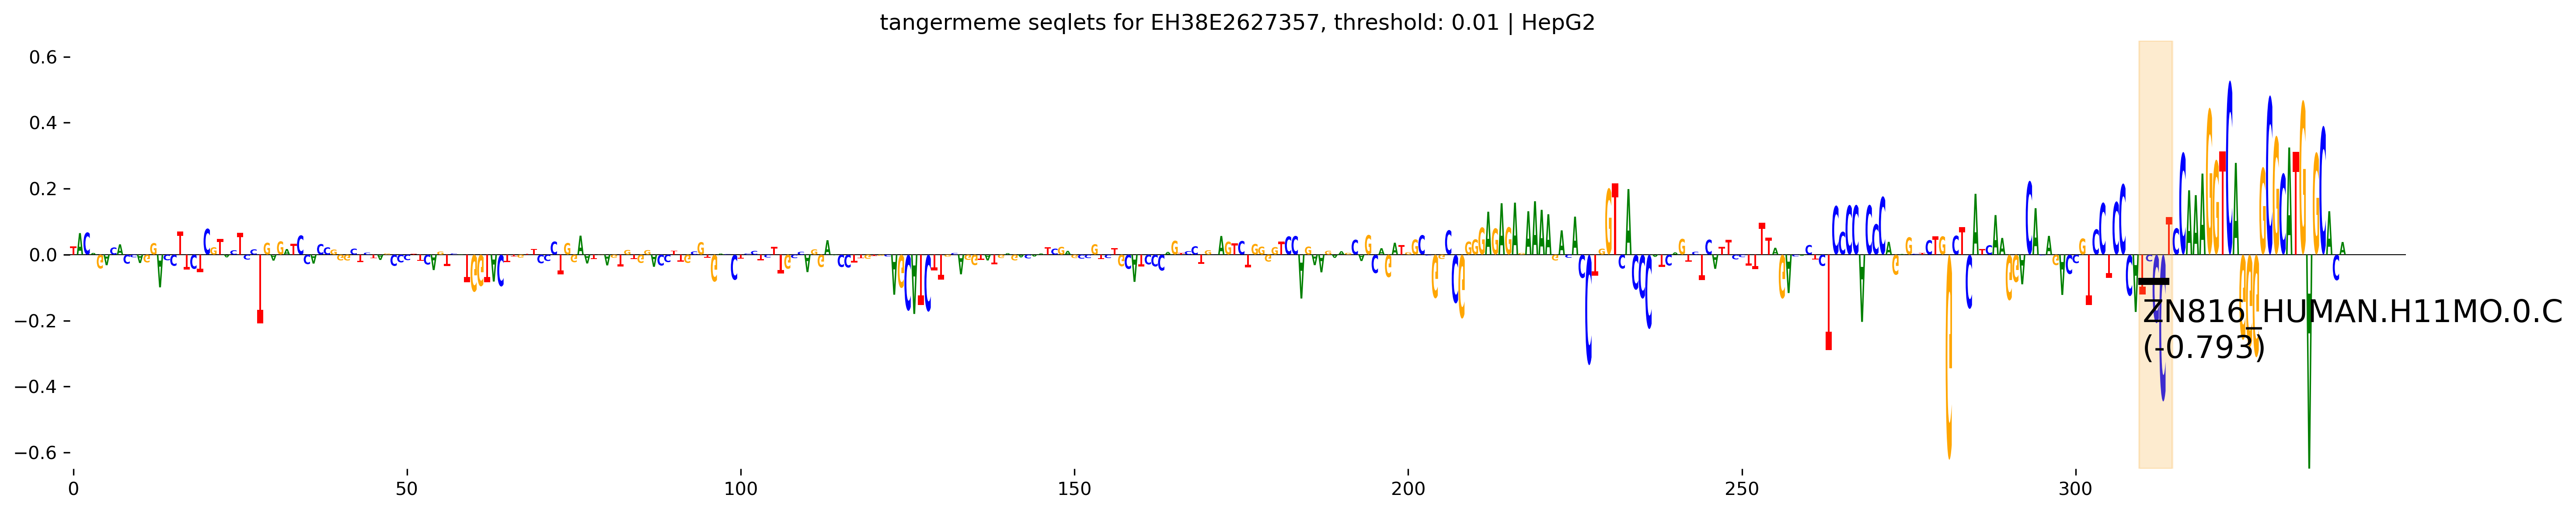

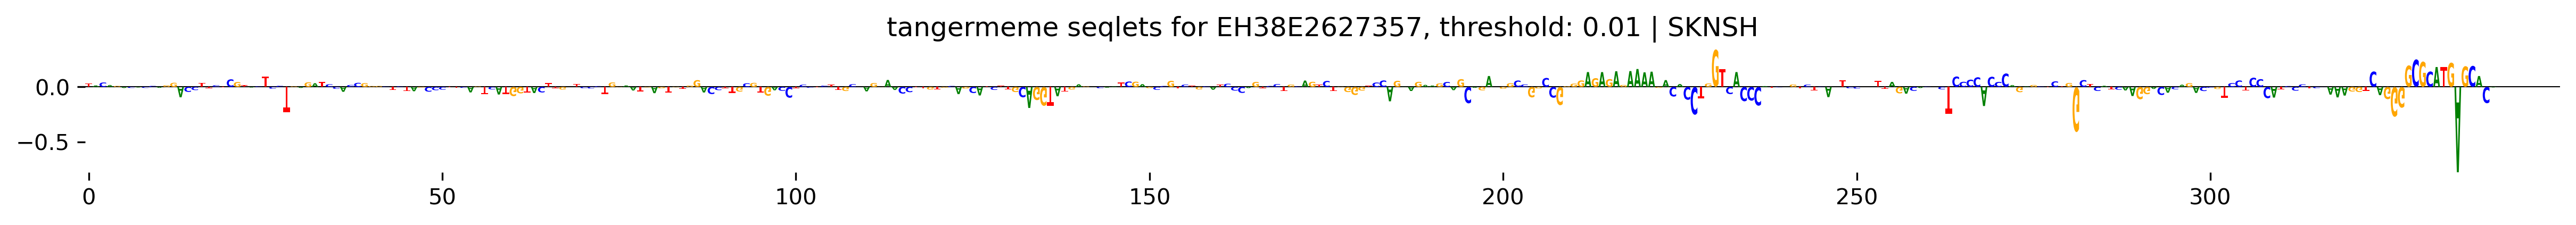

In [67]:
# emvar any
# chr8 	41668389 	41668730 	EH38E2627357
plot_logos_v2(
    8,
    'K562',
    'EH38E2627357'
)
plot_logos_v2(
    8,
    'HepG2',
    'EH38E2627357'
)
plot_logos_v2(
    8,
    'SKNSH',
    'EH38E2627357'
)